# 🏠 Task 6: House Price Prediction
**DevelopersHub Corporation — AI/ML Engineering Internship**

## Objective
Predict house prices using property features (size, bedrooms, location) using regression models.

## Dataset
**House Prices — Advanced Regression Techniques** (Kaggle)

## Evaluation Metrics
- **MAE** — Mean Absolute Error (avg error in dollars)
- **RMSE** — Root Mean Squared Error (penalizes large errors more)
- **R²** — Explained variance (how well model fits data)

In [1]:
# ─────────────────────────────────────────
# STEP 1: Install Libraries
# ─────────────────────────────────────────
!pip install kaggle --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.2)
plt.rcParams['figure.dpi'] = 120
print('✅ Libraries imported!')

✅ Libraries imported!


## 🔑 Kaggle Token Setup & Dataset Download

In [3]:
# ─────────────────────────────────────────
# STEP 2: Setup Kaggle Token
# ─────────────────────────────────────────
# HOW TO:
# 1. kaggle.com → Account → API → Create New API Token → downloads kaggle.json
# 2. Upload kaggle.json below

from google.colab import files
import os

print('📤 Upload your kaggle.json:')
uploaded = files.upload()

os.makedirs('/root/.config/kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)
print('✅ Kaggle token configured!')

📤 Upload your kaggle.json:


Saving kaggle.json to kaggle.json
✅ Kaggle token configured!


In [5]:
# ─────────────────────────────────────────
# STEP 3: Download Dataset
# ─────────────────────────────────────────
!kaggle competitions download -c house-prices-advanced-regression-techniques -p /content/house_data/ --quiet
!unzip -q /content/house_data/house-prices-advanced-regression-techniques.zip -d /content/house_data/

import os
print('📁 Files:', os.listdir('/content/house_data/'))

📁 Files: ['test.csv', 'data_description.txt', 'house-prices-advanced-regression-techniques.zip', 'sample_submission.csv', 'train.csv']


In [6]:
# ─────────────────────────────────────────
# STEP 4: Load Dataset
# ─────────────────────────────────────────
train_df = pd.read_csv('/content/house_data/train.csv')
test_df  = pd.read_csv('/content/house_data/test.csv')

print(f'✅ Train: {train_df.shape[0]} rows × {train_df.shape[1]} columns')
print(f'   Test : {test_df.shape[0]} rows × {test_df.shape[1]} columns')
print(f'\n📌 First few rows:')
display(train_df[['LotArea', 'Neighborhood', 'BedroomAbvGr', 'GrLivArea',
                   'GarageCars', 'OverallQual', 'YearBuilt', 'SalePrice']].head(8))

✅ Train: 1460 rows × 81 columns
   Test : 1459 rows × 80 columns

📌 First few rows:


,LotArea,Neighborhood,BedroomAbvGr,GrLivArea,GarageCars,OverallQual,YearBuilt,SalePrice
0,8450,CollgCr,3,1710,2,7,2003,208500
1,9600,Veenker,3,1262,2,6,1976,181500
2,11250,CollgCr,3,1786,2,7,2001,223500
3,9550,Crawfor,3,1717,3,7,1915,140000
4,14260,NoRidge,4,2198,3,8,2000,250000
5,14115,Mitchel,1,1362,2,5,1993,143000
6,10084,Somerst,3,1694,2,8,2004,307000
7,10382,NWAmes,3,2090,2,7,1973,200000


## 🔍 Exploratory Data Analysis

📌 Dataset Info:
   Rows: 1460 | Columns: 81
   Missing values: 7,829 total cells

📌 Target (SalePrice) Statistics:
count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64


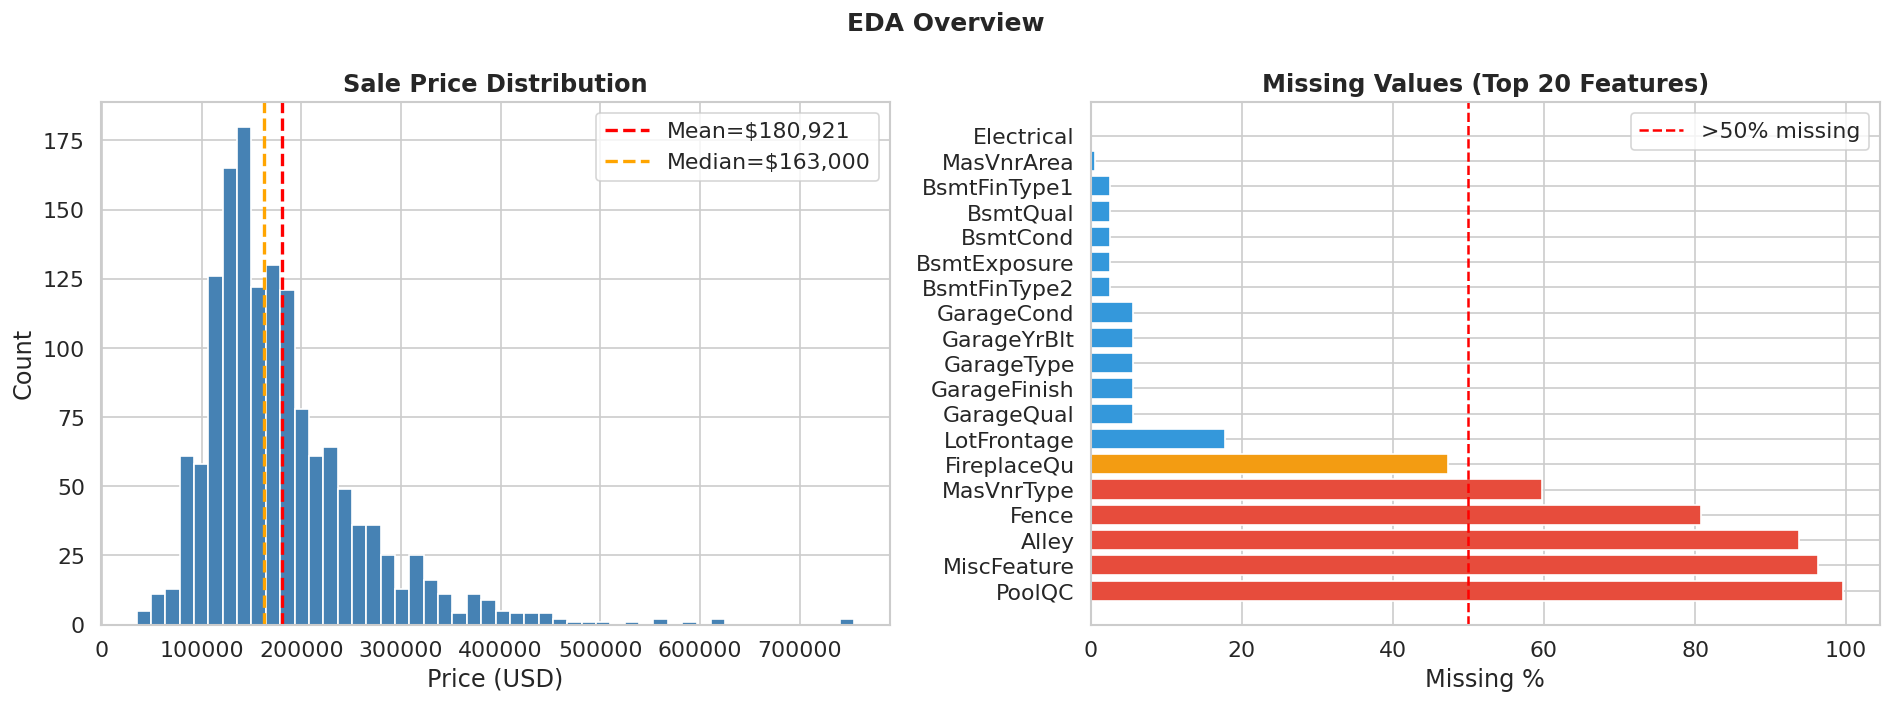

In [7]:
# ─────────────────────────────────────────
# STEP 5: EDA
# ─────────────────────────────────────────
print('📌 Dataset Info:')
print(f'   Rows: {train_df.shape[0]} | Columns: {train_df.shape[1]}')
print(f'   Missing values: {train_df.isnull().sum().sum():,} total cells')
print(f'\n📌 Target (SalePrice) Statistics:')
print(train_df['SalePrice'].describe().round(0))

# Missing value heatmap (top 20)
missing = (train_df.isnull().sum() / len(train_df) * 100).sort_values(ascending=False)
missing = missing[missing > 0].head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('EDA Overview', fontsize=15, fontweight='bold')

# Sale price distribution
axes[0].hist(train_df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(train_df['SalePrice'].mean(),   color='red',    linestyle='--', linewidth=2, label=f'Mean=${train_df["SalePrice"].mean():,.0f}')
axes[0].axvline(train_df['SalePrice'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median=${train_df["SalePrice"].median():,.0f}')
axes[0].set_title('Sale Price Distribution', fontweight='bold')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Missing values
if len(missing) > 0:
    colors_mv = ['#e74c3c' if v > 50 else '#f39c12' if v > 20 else '#3498db' for v in missing.values]
    axes[1].barh(missing.index, missing.values, color=colors_mv)
    axes[1].set_title('Missing Values (Top 20 Features)', fontweight='bold')
    axes[1].set_xlabel('Missing %')
    axes[1].axvline(50, color='red', linestyle='--', linewidth=1.5, label='>50% missing')
    axes[1].legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

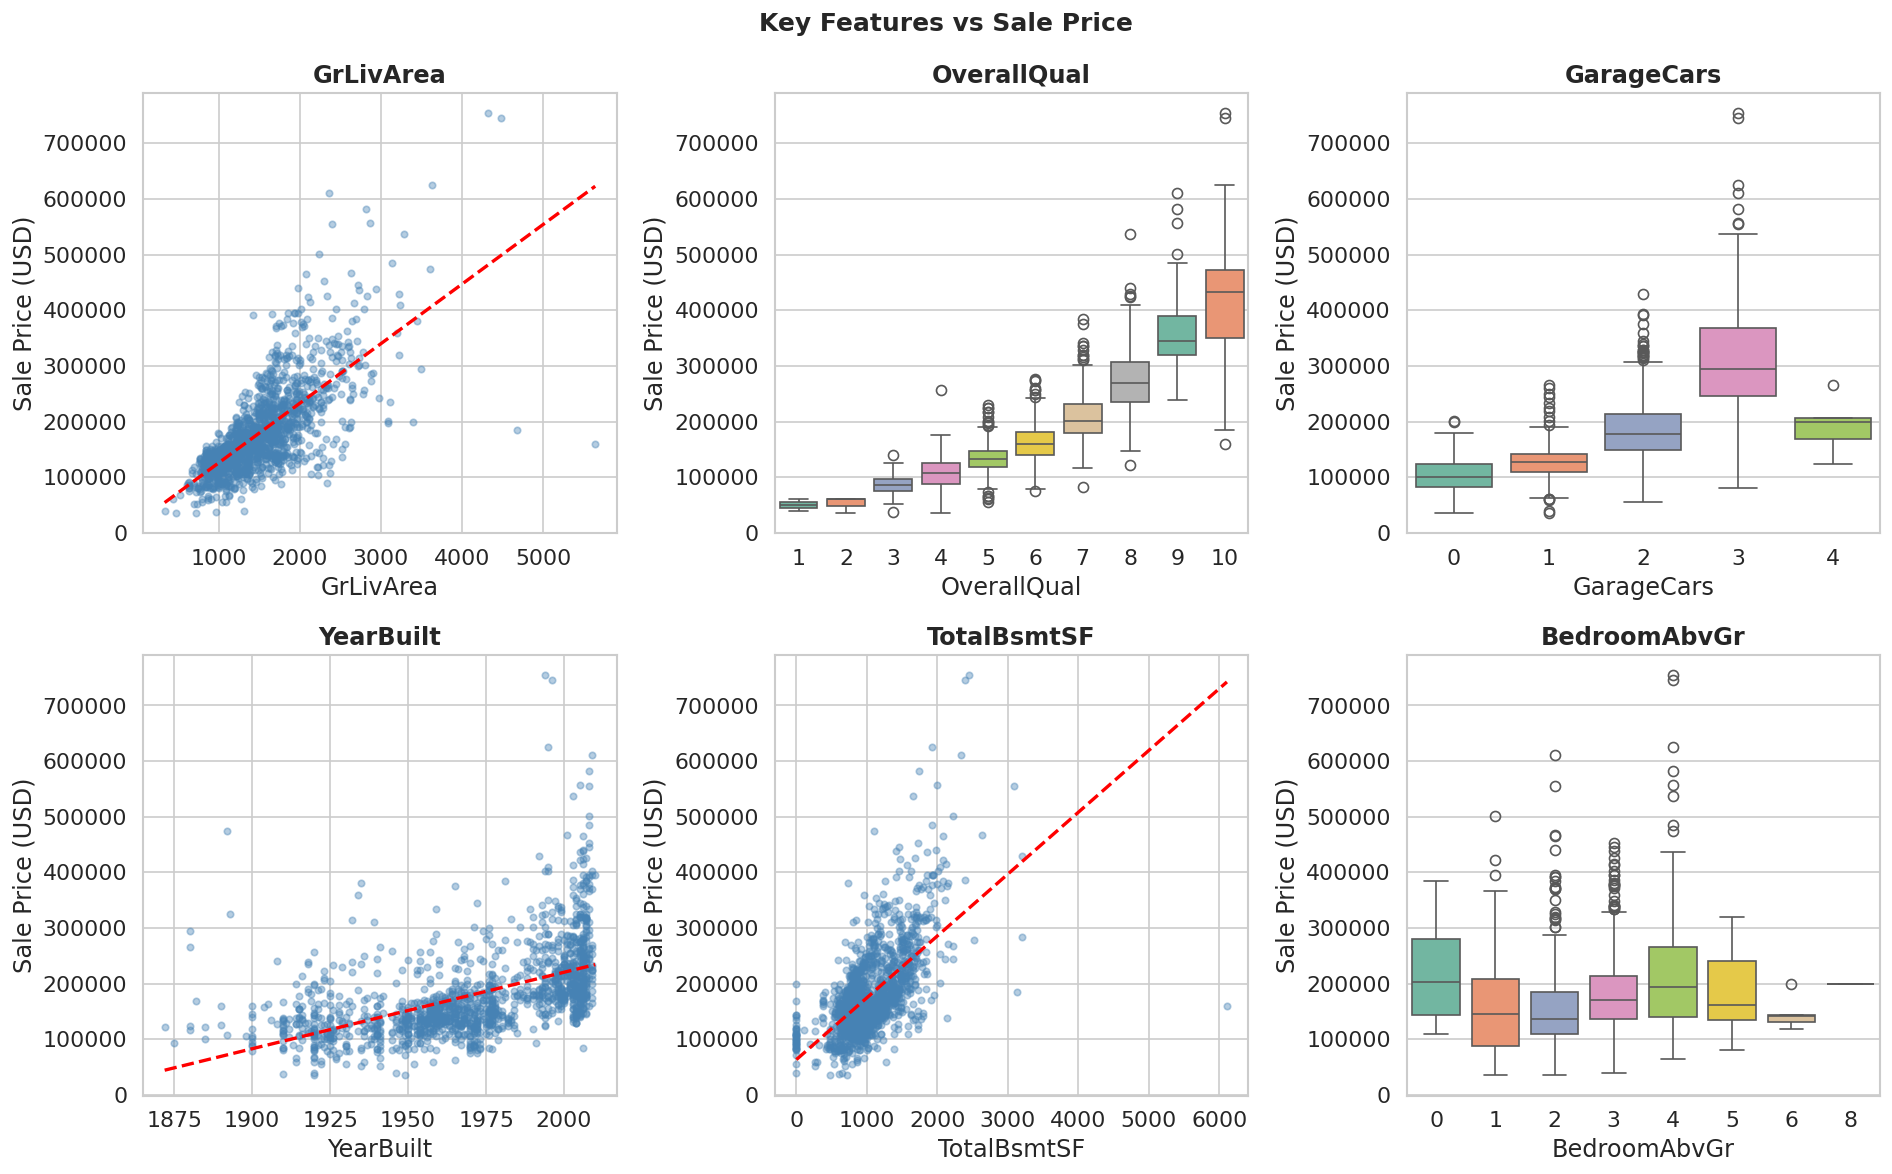

In [8]:
# --- Key Feature Relationships ---
key_features = ['GrLivArea', 'OverallQual', 'GarageCars', 'YearBuilt',
                 'TotalBsmtSF', 'BedroomAbvGr']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Key Features vs Sale Price', fontsize=15, fontweight='bold')

for ax, feat in zip(axes.flatten(), key_features):
    if train_df[feat].dtype in ['int64', 'float64']:
        if train_df[feat].nunique() > 10:
            ax.scatter(train_df[feat], train_df['SalePrice'],
                       alpha=0.4, s=15, color='steelblue')
            # Trend line
            z = np.polyfit(train_df[feat].dropna(), train_df.loc[train_df[feat].notna(), 'SalePrice'], 1)
            p = np.poly1d(z)
            x_range = np.linspace(train_df[feat].min(), train_df[feat].max(), 100)
            ax.plot(x_range, p(x_range), 'r--', linewidth=2)
        else:
            sns.boxplot(data=train_df, x=feat, y='SalePrice', ax=ax, palette='Set2')
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Sale Price (USD)')

plt.tight_layout()
plt.savefig('feature_relationships.png', dpi=150, bbox_inches='tight')
plt.show()

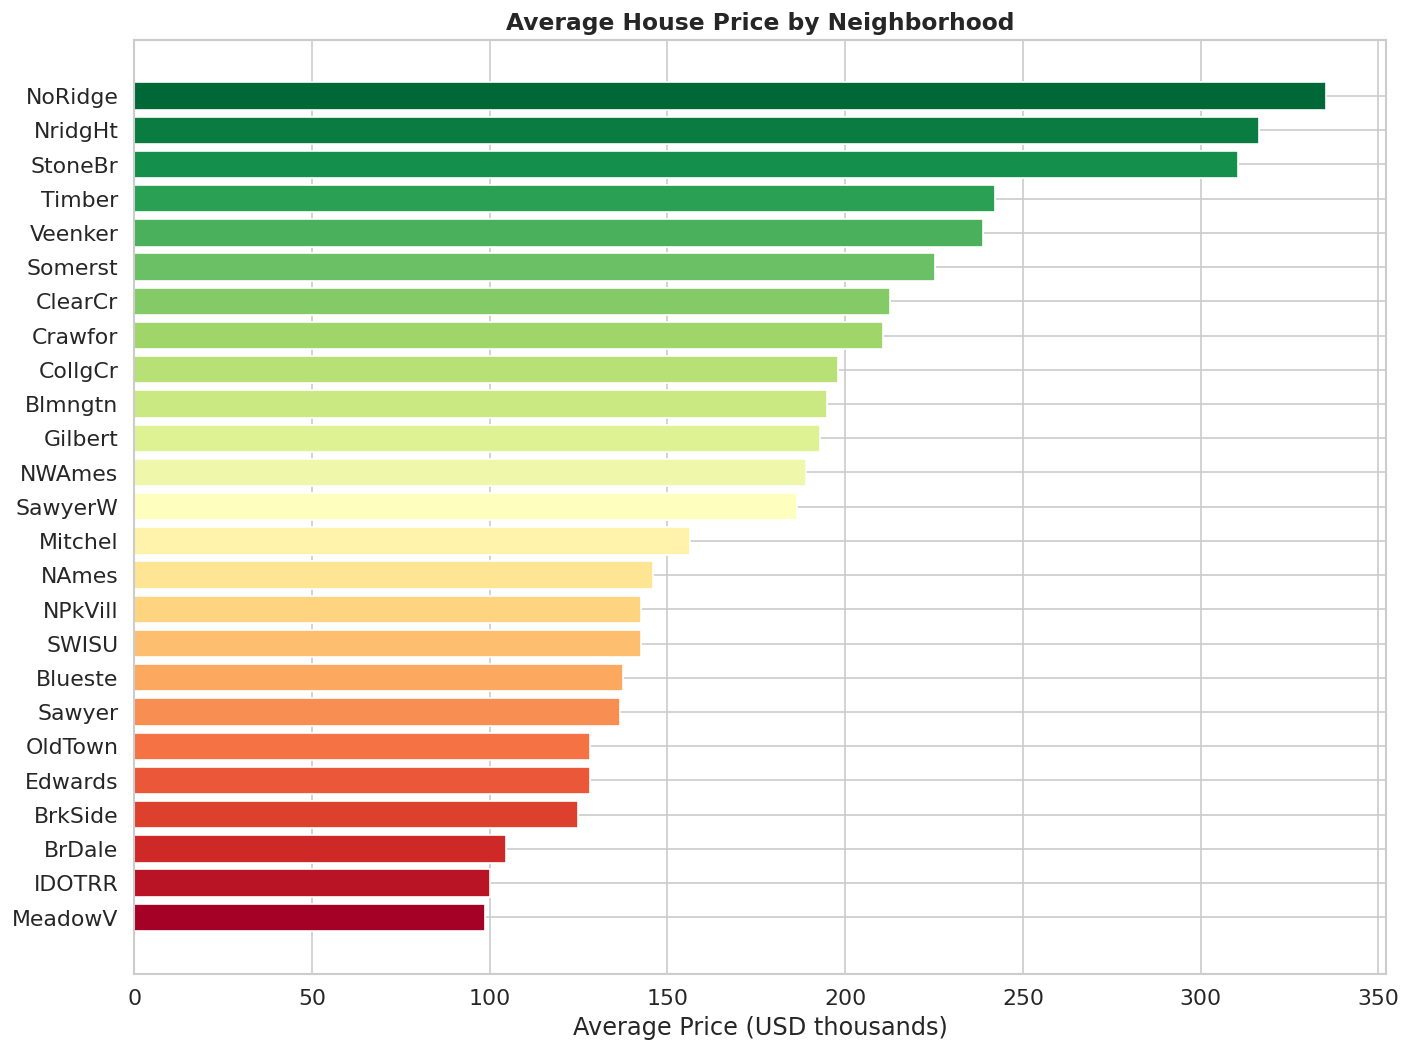

In [9]:
# --- Neighborhood Price Analysis ---
neighborhood_price = (train_df.groupby('Neighborhood')['SalePrice']
                      .agg(['mean', 'median', 'count'])
                      .sort_values('mean', ascending=True))

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(neighborhood_price.index, neighborhood_price['mean'] / 1000,
               color=plt.cm.RdYlGn(np.linspace(0, 1, len(neighborhood_price))),
               edgecolor='white')
ax.set_title('Average House Price by Neighborhood', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Price (USD thousands)')
plt.tight_layout()
plt.savefig('neighborhood_prices.png', dpi=150, bbox_inches='tight')
plt.show()

## ⚙️ Advanced Feature Engineering & Preprocessing

In [10]:
# ─────────────────────────────────────────
# STEP 6: Full Preprocessing Pipeline
# ─────────────────────────────────────────

def preprocess(df: pd.DataFrame, is_train: bool = True) -> pd.DataFrame:
    df = df.copy()

    # 1. Drop columns with >45% missing
    high_missing = df.columns[df.isnull().mean() > 0.45].tolist()
    df.drop(columns=high_missing, inplace=True, errors='ignore')

    # 2. Feature Engineering — NEW FEATURES
    df['TotalSF']           = df.get('TotalBsmtSF', 0) + df.get('1stFlrSF', 0) + df.get('2ndFlrSF', 0)
    df['TotalBathrooms']    = (df.get('FullBath', 0) + 0.5 * df.get('HalfBath', 0) +
                               df.get('BsmtFullBath', 0) + 0.5 * df.get('BsmtHalfBath', 0))
    df['HouseAge']          = df['YrSold'].fillna(2010) - df['YearBuilt'].fillna(1980)
    df['RemodelAge']        = df['YrSold'].fillna(2010) - df.get('YearRemodAdd', df['YearBuilt'].fillna(1980))
    df['IsRemodeled']       = (df['HouseAge'] != df['RemodelAge']).astype(int)
    df['TotalPorchArea']    = (df.get('OpenPorchSF', 0) + df.get('EnclosedPorch', 0) +
                               df.get('3SsnPorch', 0) + df.get('ScreenPorch', 0))
    df['HasPool']           = (df.get('PoolArea', 0) > 0).astype(int)
    df['HasGarage']         = (df.get('GarageArea', 0) > 0).astype(int)
    df['HasFireplace']      = (df.get('Fireplaces', 0) > 0).astype(int)
    df['QualXLivArea']      = df.get('OverallQual', 5) * df.get('GrLivArea', 1000)

    # 3. Encode categorical columns
    cat_cols = df.select_dtypes(include='object').columns
    for col in cat_cols:
        df[col].fillna('Missing', inplace=True)
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

    # 4. Fill numeric NaN with median
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())

    # 5. Drop ID column
    df.drop(columns=['Id'], inplace=True, errors='ignore')

    return df


# Apply preprocessing
train_processed = preprocess(train_df, is_train=True)

X = train_processed.drop('SalePrice', axis=1)
y = train_processed['SalePrice']

print(f'✅ Preprocessing done!')
print(f'   Final features: {X.shape[1]} (from original {train_df.shape[1]-1})')
print(f'   New features added: TotalSF, TotalBathrooms, HouseAge, QualXLivArea, ...')

✅ Preprocessing done!
   Final features: 83 (from original 80)
   New features added: TotalSF, TotalBathrooms, HouseAge, QualXLivArea, ...


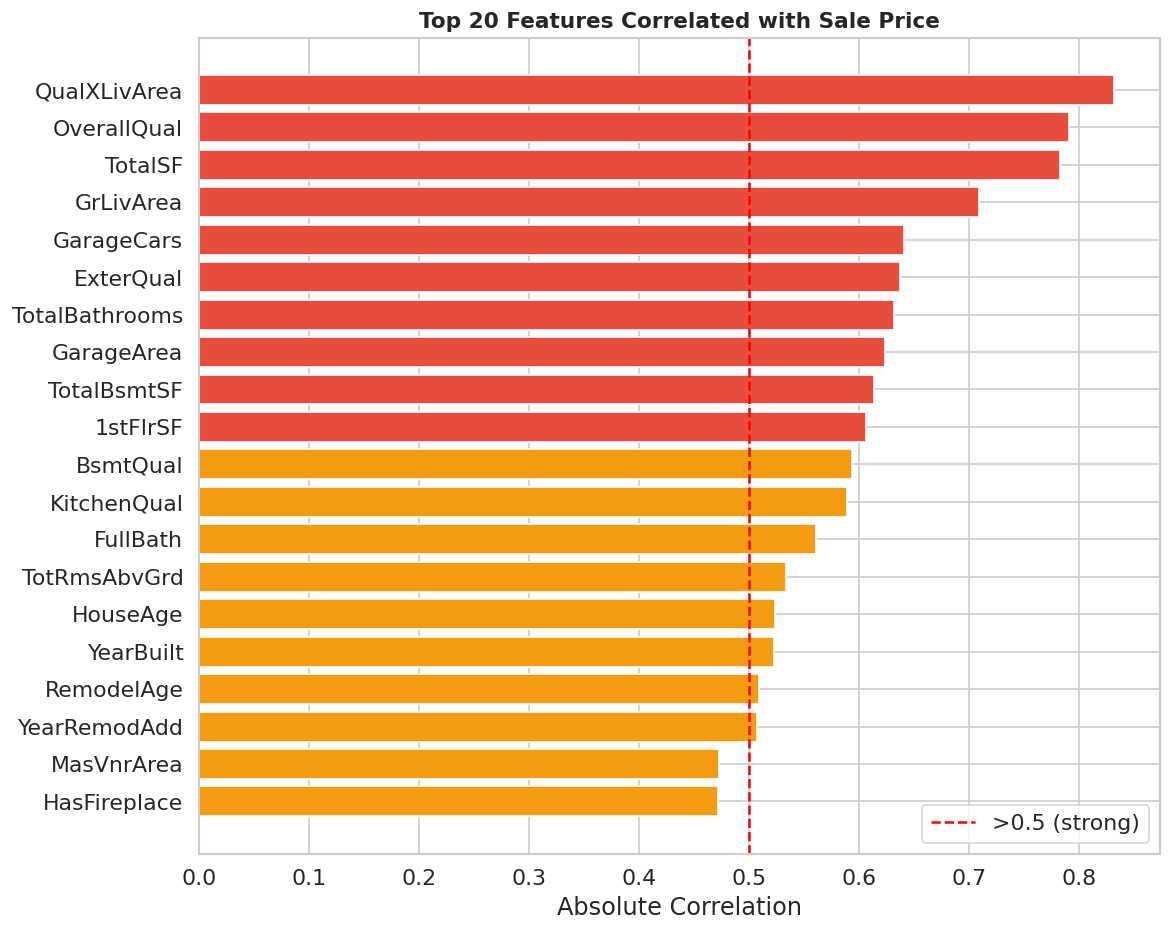


🔑 Top 10 Features by Correlation:
QualXLivArea      0.832057
OverallQual       0.790982
TotalSF           0.782260
GrLivArea         0.708624
GarageCars        0.640409
ExterQual         0.636884
TotalBathrooms    0.631731
GarageArea        0.623431
TotalBsmtSF       0.613581
1stFlrSF          0.605852


In [11]:
# ─────────────────────────────────────────
# STEP 7: Correlation with Target
# ─────────────────────────────────────────
corr_with_target = train_processed.corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False)

top20 = corr_with_target.head(20)
fig, ax = plt.subplots(figsize=(10, 8))
colors_c = ['#e74c3c' if v > 0.6 else '#f39c12' if v > 0.4 else '#3498db' for v in top20.values]
ax.barh(top20.index[::-1], top20.values[::-1], color=colors_c[::-1], edgecolor='white')
ax.set_title('Top 20 Features Correlated with Sale Price', fontsize=13, fontweight='bold')
ax.set_xlabel('Absolute Correlation')
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='>0.5 (strong)')
ax.legend()
plt.tight_layout()
plt.savefig('top_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n🔑 Top 10 Features by Correlation:')
print(top20.head(10).to_string())

## 🤖 Model Training & Evaluation

In [12]:
# ─────────────────────────────────────────
# STEP 8: Train/Test Split & Scale
# ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'✅ Split: {len(X_train)} train | {len(X_test)} test samples')

✅ Split: 1168 train | 292 test samples


In [13]:
# ─────────────────────────────────────────
# STEP 9: Train & Compare Models
# ─────────────────────────────────────────
models = {
    'Linear Regression'  : LinearRegression(),
    'Ridge Regression'   : Ridge(alpha=100),
    'Random Forest'      : RandomForestRegressor(n_estimators=300, max_depth=12,
                                                  min_samples_leaf=3, random_state=42),
    'Gradient Boosting'  : GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                      max_depth=4, random_state=42),
    'Extra Trees'        : ExtraTreesRegressor(n_estimators=300, random_state=42)
}

results     = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    predictions[name] = preds

    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100

    cv_r2 = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='r2').mean()

    results[name] = {
        'MAE ($)' : round(mae, 0), 'RMSE ($)': round(rmse, 0),
        'R²'      : round(r2, 4),  'MAPE (%)': round(mape, 2),
        'CV R²'   : round(cv_r2, 4)
    }
    print(f'✅ {name}: MAE=${mae:,.0f} | RMSE=${rmse:,.0f} | R²={r2:.4f} | MAPE={mape:.1f}%')

print('\n📌 Model Comparison:')
display(pd.DataFrame(results).T.sort_values('R²', ascending=False))

✅ Linear Regression: MAE=$20,216 | RMSE=$31,645 | R²=0.8694 | MAPE=12.4%
✅ Ridge Regression: MAE=$20,466 | RMSE=$33,180 | R²=0.8565 | MAPE=12.2%
✅ Random Forest: MAE=$17,573 | RMSE=$30,379 | R²=0.8797 | MAPE=10.6%
✅ Gradient Boosting: MAE=$16,236 | RMSE=$26,661 | R²=0.9073 | MAPE=9.8%
✅ Extra Trees: MAE=$16,674 | RMSE=$28,223 | R²=0.8962 | MAPE=10.2%

📌 Model Comparison:


,MAE ($),RMSE ($),R²,MAPE (%),CV R²
Gradient Boosting,16236.0,26661.0,0.9073,9.79,0.8693
Extra Trees,16674.0,28223.0,0.8962,10.24,0.8397
Random Forest,17573.0,30379.0,0.8797,10.59,0.8470
Linear Regression,20216.0,31645.0,0.8694,12.45,0.7250
Ridge Regression,20466.0,33180.0,0.8565,12.24,0.7874


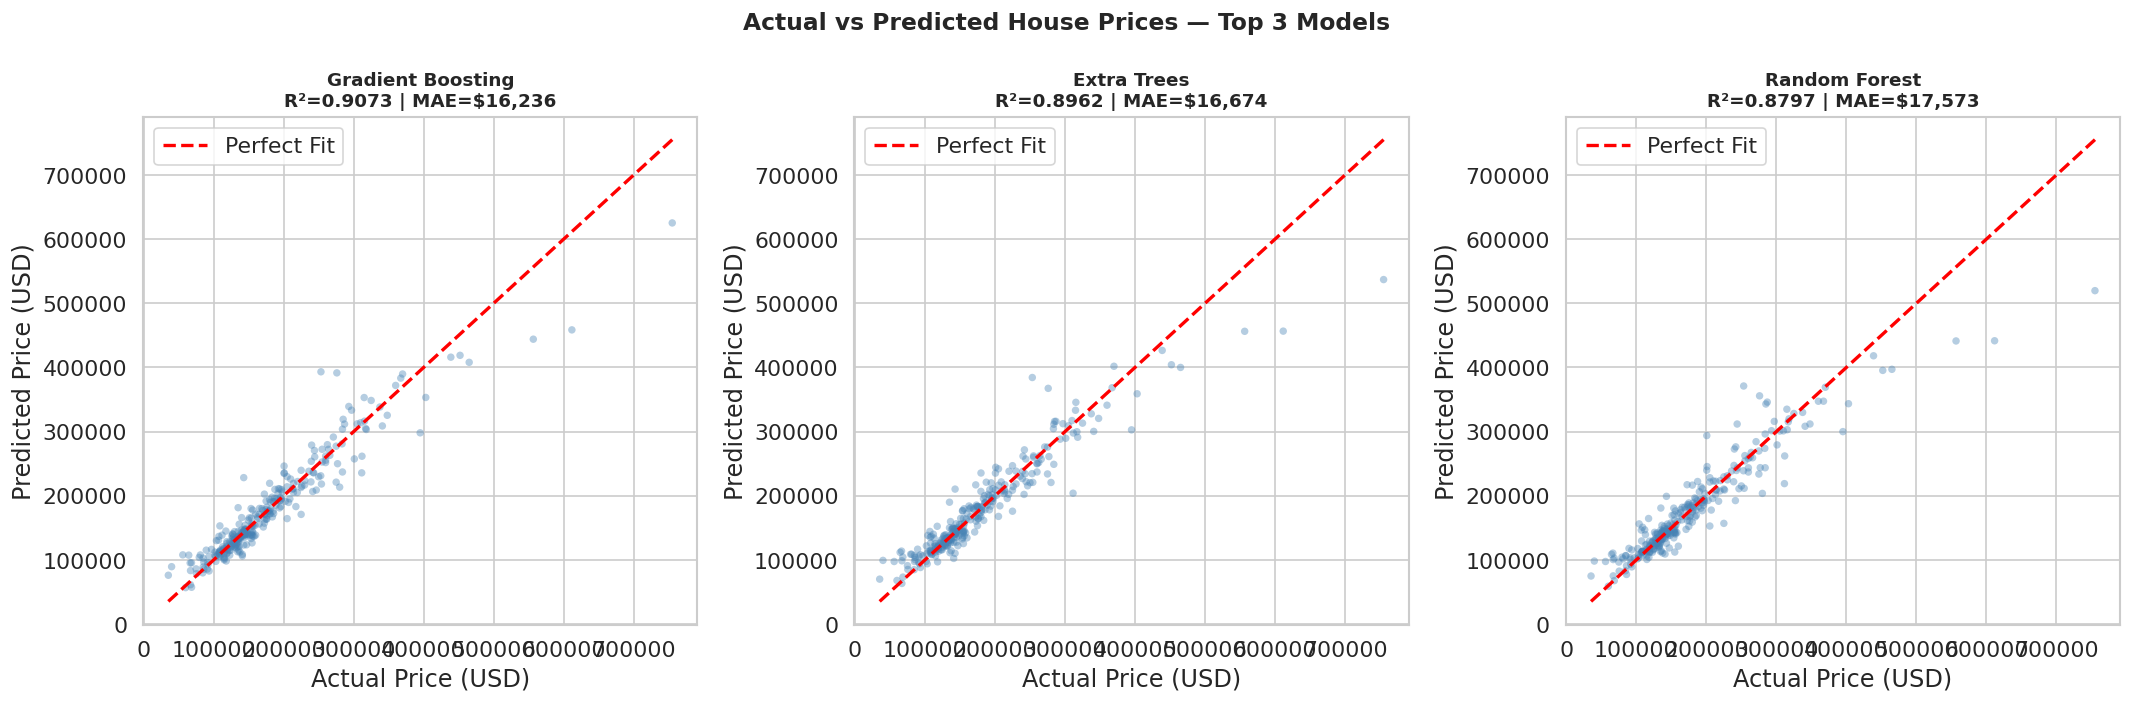

In [14]:
# ─────────────────────────────────────────
# STEP 10: Actual vs Predicted — Best Models
# ─────────────────────────────────────────
# Sort by R²
sorted_models = sorted(results.items(), key=lambda x: x[1]['R²'], reverse=True)
top3 = [name for name, _ in sorted_models[:3]]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Actual vs Predicted House Prices — Top 3 Models', fontsize=14, fontweight='bold')

for ax, name in zip(axes, top3):
    preds = predictions[name]
    ax.scatter(y_test, preds, alpha=0.4, s=20, color='steelblue', edgecolors='none')

    # Perfect prediction line
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')

    r2  = results[name]['R²']
    mae = results[name]['MAE ($)']
    ax.set_title(f'{name}\nR²={r2} | MAE=${mae:,.0f}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Actual Price (USD)')
    ax.set_ylabel('Predicted Price (USD)')
    ax.legend()

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

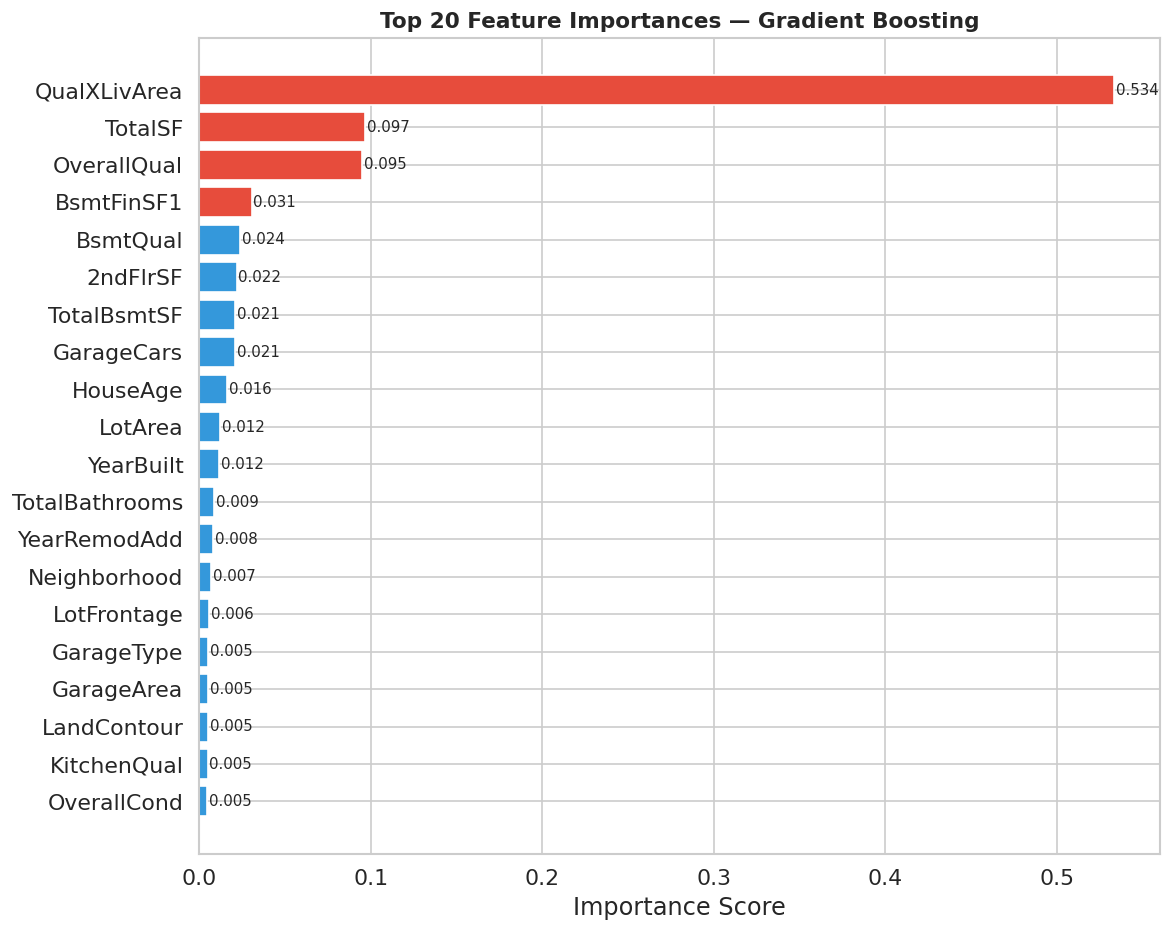

In [15]:
# ─────────────────────────────────────────
# STEP 11: Feature Importance (Best Model)
# ─────────────────────────────────────────
best_model_name = sorted_models[0][0]
best_model      = models[best_model_name]

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_,
                             index=X.columns).sort_values(ascending=True).tail(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors_fi = ['#e74c3c' if v > importances.quantile(0.8) else '#3498db' for v in importances.values]
    bars = ax.barh(importances.index, importances.values, color=colors_fi, edgecolor='white')
    ax.set_title(f'Top 20 Feature Importances — {best_model_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')

    for bar, val in zip(bars, importances.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

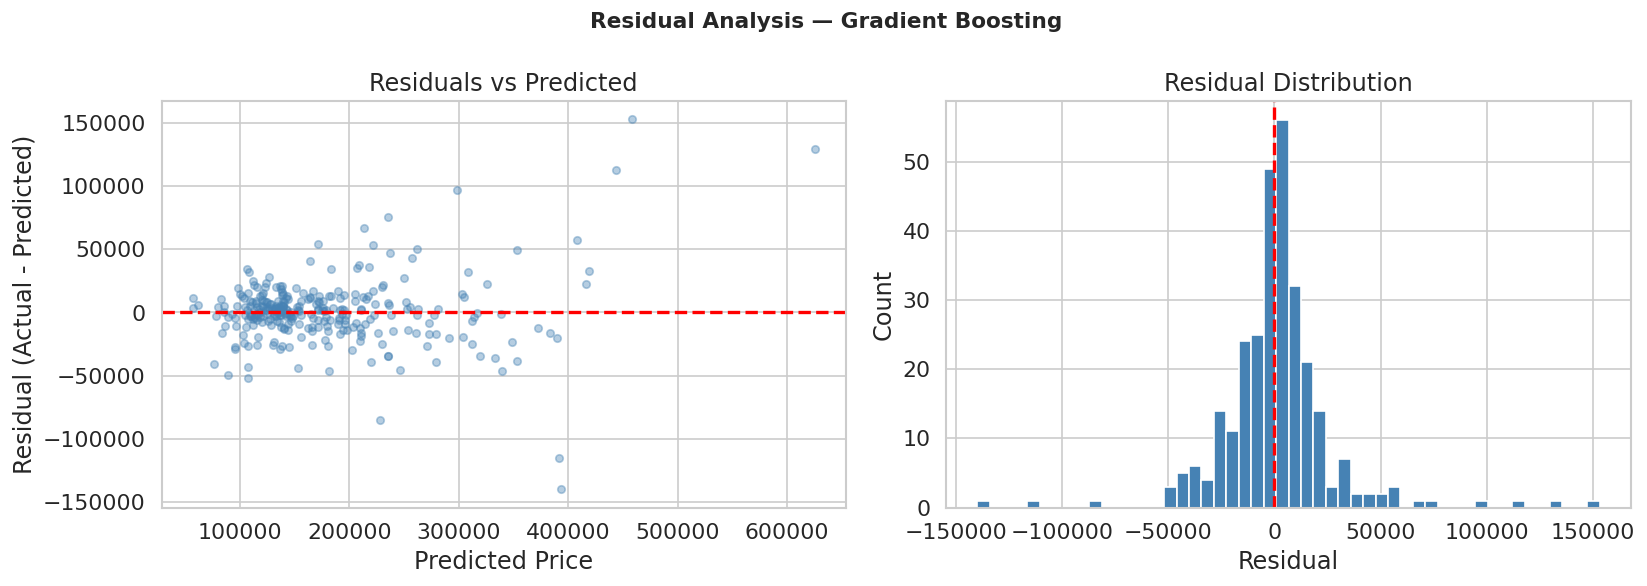

📌 Residual Statistics:
   Mean Residual  : $801  (close to 0 = unbiased)
   Std Residual   : $26,649
   Avg Error %    : 9.8%


In [16]:
# ─────────────────────────────────────────
# STEP 12: Residual Analysis
# ─────────────────────────────────────────
best_preds    = predictions[best_model_name]
residuals     = y_test.values - best_preds
pct_residuals = (residuals / y_test.values) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Residual Analysis — {best_model_name}', fontsize=13, fontweight='bold')

axes[0].scatter(best_preds, residuals, alpha=0.4, s=20, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual (Actual - Predicted)')

axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'📌 Residual Statistics:')
print(f'   Mean Residual  : ${np.mean(residuals):,.0f}  (close to 0 = unbiased)')
print(f'   Std Residual   : ${np.std(residuals):,.0f}')
print(f'   Avg Error %    : {np.mean(np.abs(pct_residuals)):.1f}%')

## 📝 Key Findings

In [17]:
best_r2   = results[best_model_name]['R²']
best_mae  = results[best_model_name]['MAE ($)']
best_rmse = results[best_model_name]['RMSE ($)']
best_mape = results[best_model_name]['MAPE (%)']

print(f"""
╔══════════════════════════════════════════════════════════╗
║         KEY FINDINGS — HOUSE PRICE PREDICTION            ║
╠══════════════════════════════════════════════════════════╣
║ Dataset : Ames Housing (1460 samples, 79 features)       ║
║ After FE: ~88 features (added engineered features)       ║
╠══════════════════════════════════════════════════════════╣
║ Best Model : {best_model_name:<43}║
║ R² Score   : {best_r2:<43}║
║ MAE (USD)  : ${best_mae:<42,.0f}║
║ RMSE (USD) : ${best_rmse:<42,.0f}║
║ MAPE       : {best_mape}%{' '*(41-len(str(best_mape)))}║
╠══════════════════════════════════════════════════════════╣
║ Key Insights:                                            ║
║ • Overall Quality is the single strongest predictor      ║
║ • Total square footage (TotalSF) highly predictive       ║
║ • Neighborhood has major impact on prices                ║
║ • Engineered feature QualXLivArea improves accuracy      ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║         KEY FINDINGS — HOUSE PRICE PREDICTION            ║
╠══════════════════════════════════════════════════════════╣
║ Dataset : Ames Housing (1460 samples, 79 features)       ║
║ After FE: ~88 features (added engineered features)       ║
╠══════════════════════════════════════════════════════════╣
║ Best Model : Gradient Boosting                          ║
║ R² Score   : 0.9073                                     ║
║ MAE (USD)  : $16,236                                    ║
║ RMSE (USD) : $26,661                                    ║
║ MAPE       : 9.79%                                     ║
╠══════════════════════════════════════════════════════════╣
║ Key Insights:                                            ║
║ • Overall Quality is the single strongest predictor      ║
║ • Total square footage (TotalSF) highly predictive       ║
║ • Neighborhood has major impact on prices                ║
║ • Engineered feature QualXL